# Cream Cheese Fermentation Model Registration

The [Cream Cheese Fermentation Paper](cream_cheese_fermentation_paper.ipynb) describes a mathematical model for the fermentation process of cream cheese. The model consists of a system of ordinary differential equations (ODEs) that describe the dynamics of bacterial concentration, lactic acid concentration, and pH values over time.

[cream_cheese_fermentation_model.py](cream_cheese_fermentation_model.py) and [cream_cheese_fermentation.yaml](cream_cheese_fermentation.yaml) formalizes this model into a Python class that can be registered with MLFlow.

> [MLFlow](https://mlflow.org/) NEEDS TO BE INSTALLED AND RUNNING IN ORDER TO REGISTER ANY MODEL. Please refer to the [root README.md](../README.md) file for instructions on how to install and run MLFlow.

/Users/diegolopezronda/Documents/github/fonterra-SWE-assessment/.venv/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


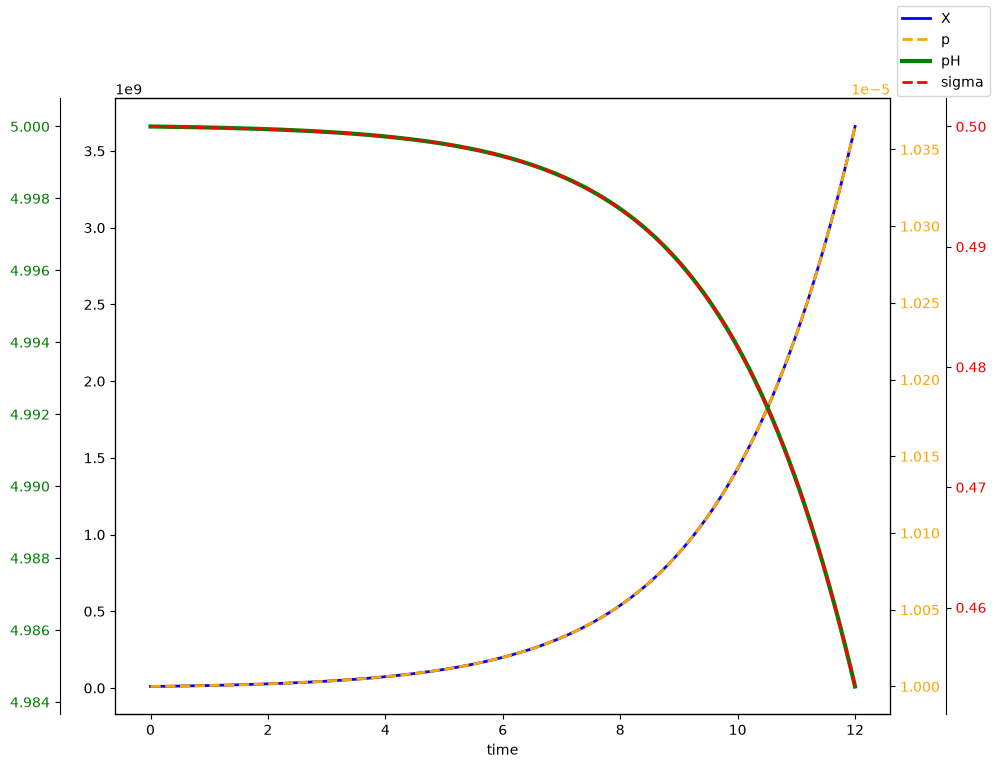

In [1]:
from plotter import plot
from cream_cheese_fermentation_model import CreamCheeseFermentationModel

x0 = 10e6
p0 = 10e-6
mu = 1.0
q = -16
c1=5
c2=12
payload = {
  "y0": [x0, p0],
  "t_start": 0.0,
  "t_end": 12, 
  "t_steps": 1000
}
kinetic_parameters = {
  "c1": c1, 
  "c2": c2, 
  "mu": mu, 
  "q": q
}
results = CreamCheeseFermentationModel().predict(
    context=None, model_input=payload, params=kinetic_parameters
)
plot(results)

In [ ]:
import mlflow
import mlflow.pyfunc
import pandas as pd
from mlflow.models import infer_signature

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Cream-Cheese-Fermentation")

# 2. Get a mock output by calling predict locally
mock_output = CreamCheeseFermentationModel().predict(
    context=None, model_input=payload, params=kinetic_parameters
)

# 3. Infer signature automatically
signature = infer_signature(
    model_input=payload, 
    model_output=mock_output,
    params=kinetic_parameters
)
model_description = """
### pH-Dependent Microbial Growth & Product Formation ODE Model
This mathematical model simulates biological growth variables ($X$) and biochemical product accumulation ($p$) 
incorporating continuous algebraic pH calculations and non-linear logistic step thresholds ($\sigma$).

#### Governing Equations:
* $pH = -\log_{10}(\max(p, 10^{-14}))$
* $\sigma = \\frac{1}{1 + e^{-c_2(pH - c_1)}}$
* $\\frac{dX}{dt} = \mu \cdot X \cdot \sigma$
* $\\frac{dp}{dt} = 10^q \cdot X \cdot \sigma$
"""
model_name = "Cream_Cheese_Fermentation"
run_id = None
with mlflow.start_run() as run:
    mlflow.pyfunc.log_model(
        name="cream_cheese_fermentation_model",
        python_model="cream_cheese_fermentation_model.py",
        artifacts={"config": "cream_cheese_fermentation.yaml"},
        registered_model_name=model_name,
        signature=signature,
    )
    run_id = run.info.run_id
    client = mlflow.tracking.MlflowClient()
    latest_versions = client.get_latest_versions(model_name)
    if latest_versions:
        # The last element or the version attribute gives you the latest number
        latest_version_num = latest_versions[0].version
        print(f"Latest version: {latest_version_num}")
        client.update_model_version(
            name=model_name,
            version=latest_version_num,  # Replace with your active version number
            description=model_description,  # Sets the "Description" field
        )

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/var/folders/df/vkc004m115d19jj0t1zww47m0000gn/T/ipykernel_1524/3884693328.py:20: SyntaxWarning: invalid escape sequence '\s'
  model_description = """
/Users/diegolopezronda/Documents/github/fonterra-SWE-assessment/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-in

Latest version: 1
🏃 View run dashing-hound-840 at: http://127.0.0.1:5000/#/experiments/1/runs/63e1828fdef54c309f1df7d9c816a71d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '1' of model 'Cream-Cheese-Fermentation'.
/var/folders/df/vkc004m115d19jj0t1zww47m0000gn/T/ipykernel_1524/3884693328.py:43: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_versions = client.get_latest_versions(model_name)


## Testing model using MLFlow API internally

In [3]:
import matplotlib.pyplot as plt

loaded_model = mlflow.pyfunc.load_model(
    f"runs:/{run_id}/cream_cheese_fermentation_model"
)

x0 = 10e6
p0 = 10e-6
mu = 1.0
q = -16
c1 = 5
c2 = 8
predict_params = {
    "model_input": {"y0": [x0, p0], "t_start": 0.0, "t_end": 12, "t_steps": 1000},
    "params": {"c1": c1, "c2": c2, "mu": mu, "q": q},
}

results = loaded_model.predict(predict_params["model_input"],predict_params["params"])
results

/Users/diegolopezronda/Documents/github/fonterra-SWE-assessment/.venv/lib/python3.12/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


,time,X,p,pH,sigma
0,0.000000,1.000000e+07,0.00001,5.000000,0.500000
1,0.012012,1.006024e+07,0.00001,5.000000,0.499999
2,0.024024,1.012084e+07,0.00001,4.999999,0.499999
3,0.036036,1.018181e+07,0.00001,4.999999,0.499998
4,0.048048,1.024315e+07,0.00001,4.999999,0.499998
...,...,...,...,...,...
995,11.951952,3.692011e+09,0.00001,4.984297,0.468634
996,11.963964,3.712850e+09,0.00001,4.984209,0.468461
997,11.975976,3.733799e+09,0.00001,4.984122,0.468286
998,11.987988,3.754858e+09,0.00001,4.984033,0.468110


Then we can store the results in MLFlow

In [4]:
if results is not None:
    with mlflow.start_run(run_name="hola"):
        mlflow.log_params(predict_params["params"])
        for step, row in results.iterrows():
           for col_name, value in row.items():
              mlflow.log_metric(key=col_name, value=value, step=int(step))
        mlflow.log_table(data=results, artifact_file="trajectory_table.json")
        print(f"Simulation Finished!")

Simulation Finished!
🏃 View run hola at: http://127.0.0.1:5000/#/experiments/1/runs/1dc32a1bdf414cf3b4a3bc7d5a148a34
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Testing the model using MLFlow API externally

To enable external access to the model, we can use the MLFlow REST API. To serve the model we can use the following command:

```bash
cd mlflow # from the root of the repo
MODEL_NAME="Cream_Cheese_Fermentation" # Your model name
PORT=8001 # The port to serve the model
VERSION_NUMBER=latest # The version number of the model to serve (can be a specific version number or "latest")
mlflow models serve -m "models:/$MODEL_NAME/$VERSION_NUMBER" --port $PORT --env-manager local
``` 
example:

```bash
mlflow models serve -m "models:/Cream_Cheese_Fermentation/latest" --port 8001 --env-manager local
```

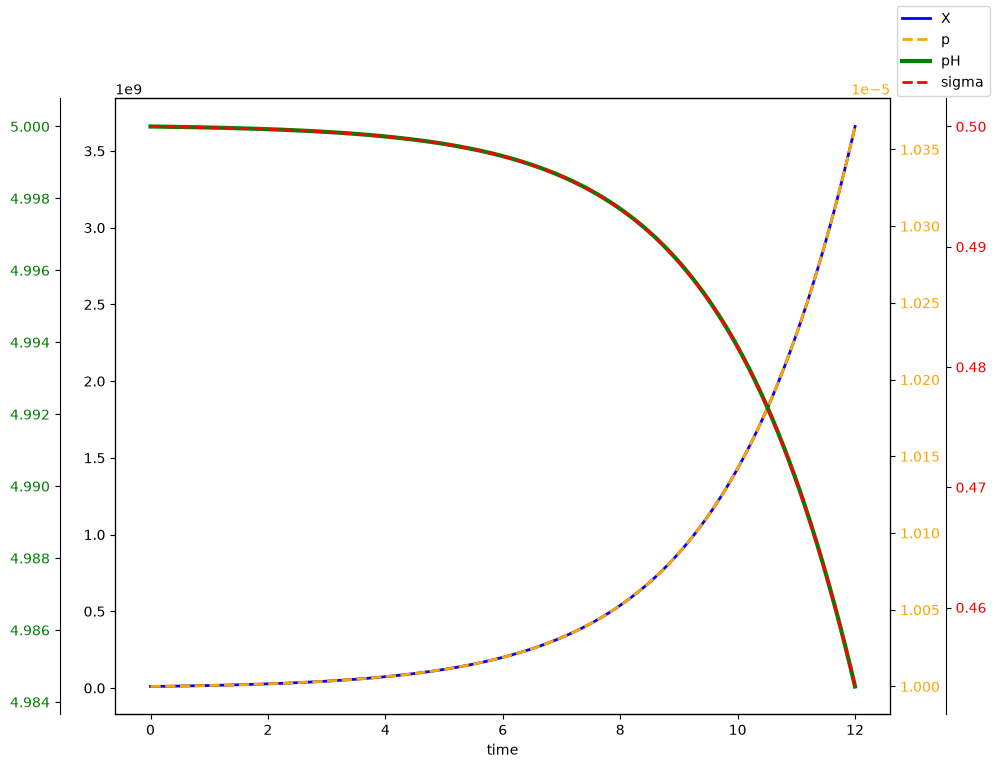

In [5]:
import requests
import json
import pandas as pd

# Your API endpoint
port = 8001 
url = f"http://127.0.0.1:{port}/invocations"

x0 = 10e6
p0 = 10e-6
mu = 1.0
q = -16
c1 = 5
c2 = 12
predict_params = {
    "dataframe_records": [
        {"y0": [x0, p0], "t_start": 0.0, "t_end": 12, "t_steps": 1000}
    ],
    "params": {"c1": c1, "c2": c2, "mu": mu, "q": q},
}

response = requests.post(url, json=predict_params)
if response.status_code == 200:
    predictions = response.json()["predictions"]
    df_results = pd.DataFrame(predictions)
    plot(df_results)
else:
    print(f"Request failed with status code: {response.status_code}")
    print(f"Response content: {response.text}")